# CSCN8020 — Assignment 2: Q-Learning on the Taxi Gymnasium Environment

---

## Introduction to the Taxi Problem

The **Taxi-v4** environment from the [Gymnasium](https://gymnasium.farama.org/) library simulates a grid-world task where a taxi must navigate to pick up a passenger and drop them off at the correct destination. The environment has:

- **500 discrete states** encoding the taxi position (25 cells), passenger location (5 options including in-taxi), and destination (4 options).
- **6 discrete actions**: move south, north, east, west, pickup, and drop-off.
- **Reward structure**: −1 per step, +20 for a successful delivery, −10 for illegal pickup or drop-off.

The Taxi problem is a classic testbed for tabular Reinforcement Learning algorithms because it requires credit assignment across multiple time steps, requires an agent to learn both navigation and task sequencing, and has a small enough state-action space to allow a complete Q-table to be stored explicitly.

---

## Explanation of Q-Learning

**Q-Learning** (Watkins & Dayan, 1992) is a model-free, off-policy Temporal-Difference (TD) control algorithm. It learns the optimal action-value function $Q^*(s, a)$ — the expected cumulative discounted return when taking action $a$ in state $s$ and thereafter following the optimal policy — directly from experience, without requiring a model of the environment.

The algorithm maintains a table $Q(s, a)$ for every state-action pair. After each transition $(s, a, r, s')$, the table is updated using the **Q-Learning update rule**:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

where:
- $\alpha \in (0, 1]$ is the **learning rate** (how much new information overrides old)
- $\gamma \in [0, 1]$ is the **discount factor** (how much future rewards are valued vs immediate)
- $r$ is the immediate reward received
- $\max_{a'} Q(s', a')$ is the bootstrap target — the best known value from the next state

The term in brackets is the **TD error**: the difference between the current estimate and the updated (bootstrapped) target. This is the core of temporal-difference learning.

### Q-Learning Pseudocode (Sutton & Barto, 2018, p. 131)

```
Initialize Q(s, a) for all s ∈ S, a ∈ A(s); Q(terminal, ·) = 0
Loop for each episode:
    Initialize S
    Loop for each step:
        Choose A from S using policy derived from Q (e.g., ε-greedy)
        Take action A, observe R, S'
        Q(S, A) ← Q(S, A) + α [R + γ max_a Q(S', a) − Q(S, A)]
        S ← S'
    until S is terminal
```

---

## Action Space

The Taxi environment has **6 discrete actions**:

| Action | Meaning |
|--------|-------------------|
| 0 | Move South (down) |
| 1 | Move North (up) |
| 2 | Move East (right) |
| 3 | Move West (left) |
| 4 | Pickup passenger |
| 5 | Drop-off passenger |

Movement actions are always valid but may be blocked by walls. Pickup and drop-off are only valid at specific locations and conditions; executing them illegally incurs a −10 penalty.

---

## Observation Space

The observation is a **single integer in [0, 499]** encoding the full state:

$$\text{state} = ((\text{taxi\_row} \times 5 + \text{taxi\_col}) \times 5 + \text{passenger\_location}) \times 4 + \text{destination}$$

- **Taxi position**: 5 rows × 5 cols = 25 positions
- **Passenger location**: 4 fixed locations (R, G, Y, B) + 1 (in taxi) = 5 options
- **Destination**: 4 fixed locations (R, G, Y, B)

Total: 25 × 5 × 4 = **500 states**

---

## Reward Structure

| Event | Reward |
|----------------------------------------|--------|
| Every time step (default step cost) | −1 |
| Successful passenger delivery | +20 |
| Illegal pickup or drop-off action | −10 |

The step penalty encourages the agent to reach the destination as efficiently as possible. The illegal action penalties discourage random pickup/drop-off attempts. The +20 delivery reward provides the primary learning signal.

---

## Task 1 — Q-Learning Implementation

The following code implements Q-Learning using an object-oriented architecture. The design separates concerns into distinct classes:

- **`TaxiEnvironmentManager`** — wraps the Gymnasium environment, handles resets, steps, and decoding.
- **`QLearningAgent`** — owns the Q-table, implements ε-greedy action selection, and performs Q-value updates.
- **`MetricsLogger`** — collects per-episode rewards, steps, and rolling averages; also writes a log file.
- **`PlotManager`** — generates and saves all required plots.
- **`QLearningTrainer`** — runs the training loop, coordinating the agent, environment, and logger.
- **`ExperimentRunner`** — orchestrates multiple experiments with different hyperparameters.


In [1]:
# ── Required Imports ──────────────────────────────────────────────────────────
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import logging
import os
import time
from datetime import datetime
from typing import List, Dict, Tuple, Optional

print(f"Gymnasium version : {gym.__version__}")
print(f"NumPy version     : {np.__version__}")
print(f"Pandas version    : {pd.__version__}")
print("All imports successful.")

Gymnasium version : 1.3.0
NumPy version     : 2.4.4
Pandas version    : 3.0.2
All imports successful.


In [2]:
# ── TaxiEnvironmentManager ────────────────────────────────────────────────────
class TaxiEnvironmentManager:
    """
    Wraps the Gymnasium Taxi environment.
    Responsible for: creation, reset, step, state decoding, and cleanup.
    """

    def __init__(self, env_id: str = "Taxi-v4", seed: int = 42):
        self.env_id = env_id
        self.seed = seed
        self.env = gym.make(env_id)
        self.n_states: int = self.env.observation_space.n     # 500
        self.n_actions: int = self.env.action_space.n         # 6
        self.action_meanings = [
            "South", "North", "East", "West", "Pickup", "Dropoff"
        ]

    def reset(self) -> int:
        """Reset the environment and return the initial state."""
        state, _ = self.env.reset(seed=self.seed)
        return int(state)

    def step(self, action: int) -> Tuple[int, float, bool]:
        """
        Take one step.
        Returns: (next_state, reward, done)
        """
        obs, reward, terminated, truncated, _ = self.env.step(action)
        done = terminated or truncated
        return int(obs), float(reward), done

    def decode_state(self, state: int) -> Dict:
        """Decode a scalar state into its human-readable components."""
        dest        = state % 4
        state       //= 4
        pass_loc    = state % 5
        state       //= 5
        taxi_col    = state % 5
        taxi_row    = state // 5
        loc_names   = ["Red", "Green", "Yellow", "Blue", "In Taxi"]
        return {
            "taxi_row"          : taxi_row,
            "taxi_col"          : taxi_col,
            "passenger_location": loc_names[pass_loc],
            "destination"       : loc_names[dest],
        }

    def close(self):
        self.env.close()

    def __repr__(self):
        return (f"TaxiEnvironmentManager(env='{self.env_id}', "
                f"states={self.n_states}, actions={self.n_actions})")


# Quick sanity check
env_mgr = TaxiEnvironmentManager()
print(env_mgr)
s0 = env_mgr.reset()
print(f"Initial state: {s0}  →  {env_mgr.decode_state(s0)}")
env_mgr.close()

TaxiEnvironmentManager(env='Taxi-v4', states=500, actions=6)
Initial state: 386  →  {'taxi_row': 3, 'taxi_col': 4, 'passenger_location': 'Green', 'destination': 'Yellow'}


In [3]:
# ── QLearningAgent ────────────────────────────────────────────────────────────
class QLearningAgent:
    """
    Implements the Q-Learning algorithm (Watkins & Dayan, 1992).

    Corresponds to Sutton & Barto (2018) Algorithm: Tabular Q-Learning, p. 131.

    Responsibilities:
      - Initialise Q(s, a) ← 0  [pseudocode line 1]
      - Choose A from S using ε-greedy  [pseudocode line 4]
      - Apply Q-Learning update rule    [pseudocode line 6]
    """

    def __init__(
        self,
        n_states    : int,
        n_actions   : int,
        alpha       : float = 0.1,   # learning rate
        gamma       : float = 0.9,   # discount factor
        epsilon     : float = 0.1,   # exploration rate
        seed        : int   = 42,
    ):
        self.n_states  = n_states
        self.n_actions = n_actions
        self.alpha     = alpha
        self.gamma     = gamma
        self.epsilon   = epsilon
        self.rng       = np.random.default_rng(seed)

        # Pseudocode: "Initialize Q(s, a) for all s ∈ S, a ∈ A(s)"
        self.q_table = np.zeros((n_states, n_actions), dtype=np.float64)

    def select_action(self, state: int) -> int:
        """
        ε-greedy action selection.
        Pseudocode: "Choose A from S using policy derived from Q"

        With probability ε  → explore (random action)
        With probability 1-ε → exploit (greedy action)
        """
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(self.n_actions))  # explore
        return int(np.argmax(self.q_table[state]))         # exploit

    def update(
        self,
        state      : int,
        action     : int,
        reward     : float,
        next_state : int,
        done       : bool,
    ) -> float:
        """
        Apply the Q-Learning update rule.
        Pseudocode line 6:
            Q(S,A) ← Q(S,A) + α[R + γ max_a Q(S',a) − Q(S,A)]

        Returns the TD error for monitoring.
        """
        # Bootstrap target: 0 if terminal, else discounted best next value
        best_next = 0.0 if done else float(np.max(self.q_table[next_state]))

        td_target = reward + self.gamma * best_next          # R + γ max Q(S',a)
        td_error  = td_target - self.q_table[state, action]  # target − current

        self.q_table[state, action] += self.alpha * td_error # update
        return td_error

    def greedy_action(self, state: int) -> int:
        """Pure greedy action for policy evaluation (no exploration)."""
        return int(np.argmax(self.q_table[state]))

    def get_policy(self) -> np.ndarray:
        """Return the greedy policy derived from the current Q-table."""
        return np.argmax(self.q_table, axis=1)

    def __repr__(self):
        return (
            f"QLearningAgent(α={self.alpha}, γ={self.gamma}, ε={self.epsilon}, "
            f"Q-table shape={self.q_table.shape})"
        )


agent = QLearningAgent(n_states=500, n_actions=6)
print(agent)
print(f"Q-table initialized to zeros: {np.all(agent.q_table == 0)}")

QLearningAgent(α=0.1, γ=0.9, ε=0.1, Q-table shape=(500, 6))
Q-table initialized to zeros: True


In [4]:
# ── MetricsLogger ─────────────────────────────────────────────────────────────
class MetricsLogger:
    """
    Records per-episode training metrics and writes a structured log file.
    """

    LOG_FILE = "training.log"

    def __init__(self, experiment_name: str = "baseline", log_interval: int = 500):
        self.experiment_name = experiment_name
        self.log_interval    = log_interval
        self.episode_rewards : List[float] = []
        self.episode_steps   : List[int]   = []
        self._ep_reward = 0.0
        self._ep_steps  = 0

        # File logger
        self.logger = logging.getLogger(experiment_name)
        self.logger.setLevel(logging.DEBUG)
        # avoid duplicate handlers if cell is re-run
        if not self.logger.handlers:
            fh = logging.FileHandler(self.LOG_FILE, mode="a", encoding="utf-8")
            fh.setFormatter(logging.Formatter(
                "%(asctime)s | %(levelname)-7s | %(name)s | %(message)s",
                datefmt="%Y-%m-%d %H:%M:%S",
            ))
            self.logger.addHandler(fh)

    def log_start(self, hyperparams: Dict):
        self.logger.info(f"{'='*60}")
        self.logger.info(f"EXPERIMENT: {self.experiment_name}")
        self.logger.info(f"Hyperparameters: {hyperparams}")
        self.logger.info(f"Training started.")

    def record_step(self, reward: float):
        self._ep_reward += reward
        self._ep_steps  += 1

    def end_episode(self, episode: int):
        self.episode_rewards.append(self._ep_reward)
        self.episode_steps.append(self._ep_steps)
        if (episode + 1) % self.log_interval == 0:
            avg = np.mean(self.episode_rewards[-self.log_interval:])
            self.logger.info(
                f"Episode {episode+1:>6} | "
                f"Avg reward (last {self.log_interval}): {avg:+.2f} | "
                f"Steps: {self._ep_steps}"
            )
        self._ep_reward = 0.0
        self._ep_steps  = 0

    def log_final(self, eval_rewards: List[float]):
        self.logger.info(
            f"Training complete. "
            f"Total episodes: {len(self.episode_rewards)} | "
            f"Avg eval reward: {np.mean(eval_rewards):.2f}"
        )

    def rolling_average(self, window: int = 100) -> np.ndarray:
        rewards = np.array(self.episode_rewards)
        return pd.Series(rewards).rolling(window, min_periods=1).mean().values

    def summary(self) -> Dict:
        return {
            "total_episodes"    : len(self.episode_rewards),
            "total_steps"       : sum(self.episode_steps),
            "mean_reward"       : np.mean(self.episode_rewards),
            "mean_steps"        : np.mean(self.episode_steps),
            "final_avg_reward"  : np.mean(self.episode_rewards[-500:]),
        }

print("MetricsLogger defined.")

MetricsLogger defined.


In [5]:
# ── PlotManager ───────────────────────────────────────────────────────────────
class PlotManager:
    """
    Generates and saves training metric plots.
    """

    STYLE = "seaborn-v0_8-darkgrid"

    @staticmethod
    def plot_training_metrics(
        logger    : MetricsLogger,
        title     : str = "Q-Learning Training Metrics",
        save_path : Optional[str] = None,
    ):
        """Plot reward per episode, steps per episode, and rolling average return."""
        with plt.style.context(PlotManager.STYLE):
            fig = plt.figure(figsize=(16, 12))
            gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

            episodes     = np.arange(1, len(logger.episode_rewards) + 1)
            rewards      = np.array(logger.episode_rewards)
            steps        = np.array(logger.episode_steps)
            rolling_avg  = logger.rolling_average(window=100)

            # — Plot 1: Total reward per episode
            ax1 = fig.add_subplot(gs[0, 0])
            ax1.plot(episodes, rewards, alpha=0.35, color="steelblue", linewidth=0.6, label="Episode reward")
            ax1.plot(episodes, rolling_avg, color="darkorange", linewidth=1.8, label="100-ep rolling avg")
            ax1.set_title("Total Reward per Episode", fontsize=13, fontweight="bold")
            ax1.set_xlabel("Episode")
            ax1.set_ylabel("Return")
            ax1.legend()

            # — Plot 2: Steps per episode
            ax2 = fig.add_subplot(gs[0, 1])
            ax2.plot(episodes, steps, alpha=0.35, color="mediumseagreen", linewidth=0.6, label="Steps")
            ax2.plot(
                episodes,
                pd.Series(steps).rolling(100, min_periods=1).mean().values,
                color="darkgreen", linewidth=1.8, label="100-ep rolling avg",
            )
            ax2.set_title("Steps per Episode", fontsize=13, fontweight="bold")
            ax2.set_xlabel("Episode")
            ax2.set_ylabel("Steps")
            ax2.legend()

            # — Plot 3: Rolling average return (larger)
            ax3 = fig.add_subplot(gs[1, :])
            ax3.plot(episodes, rolling_avg, color="darkorange", linewidth=2.0)
            ax3.axhline(y=rolling_avg[-1], color="red", linestyle="--", alpha=0.7,
                        label=f"Final avg: {rolling_avg[-1]:.2f}")
            ax3.fill_between(episodes, rolling_avg, alpha=0.15, color="darkorange")
            ax3.set_title("Average Return Over Time (100-Episode Rolling Window)",
                          fontsize=13, fontweight="bold")
            ax3.set_xlabel("Episode")
            ax3.set_ylabel("Avg Return")
            ax3.legend()

            fig.suptitle(title, fontsize=15, fontweight="bold", y=1.01)
            plt.tight_layout()

            if save_path:
                plt.savefig(save_path, dpi=120, bbox_inches="tight")
                print(f"Plot saved → {save_path}")
            plt.show()

    @staticmethod
    def plot_comparison(
        experiment_results : Dict[str, MetricsLogger],
        title              : str = "Hyperparameter Comparison",
        save_path          : Optional[str] = None,
    ):
        """Overlay rolling average rewards for multiple experiments."""
        with plt.style.context(PlotManager.STYLE):
            fig, axes = plt.subplots(1, 2, figsize=(16, 5))

            colors = plt.cm.tab10(np.linspace(0, 0.9, len(experiment_results)))
            for (name, logger), color in zip(experiment_results.items(), colors):
                eps    = np.arange(1, len(logger.episode_rewards) + 1)
                ravg   = logger.rolling_average(100)
                rsteps = pd.Series(logger.episode_steps).rolling(100, min_periods=1).mean().values
                axes[0].plot(eps, ravg,   color=color, linewidth=1.6, label=name)
                axes[1].plot(eps, rsteps, color=color, linewidth=1.6, label=name)

            axes[0].set_title("Avg Return (100-ep rolling)", fontweight="bold")
            axes[0].set_xlabel("Episode")
            axes[0].set_ylabel("Avg Return")
            axes[0].legend(fontsize=8)

            axes[1].set_title("Avg Steps (100-ep rolling)", fontweight="bold")
            axes[1].set_xlabel("Episode")
            axes[1].set_ylabel("Avg Steps")
            axes[1].legend(fontsize=8)

            fig.suptitle(title, fontsize=14, fontweight="bold")
            plt.tight_layout()

            if save_path:
                plt.savefig(save_path, dpi=120, bbox_inches="tight")
                print(f"Plot saved → {save_path}")
            plt.show()

print("PlotManager defined.")

PlotManager defined.


In [6]:
# ── QLearningTrainer ──────────────────────────────────────────────────────────
class QLearningTrainer:
    """
    Runs the Q-Learning training loop.

    Maps exactly to the full Q-Learning pseudocode in Sutton & Barto (2018, p.131):

        Loop for each episode:
            S ← env.reset()                              [line A]
            Loop for each step:
                A ← agent.select_action(S)               [line B]
                S', R, done ← env.step(A)                [line C]
                Q(S,A) updated via agent.update(...)      [line D]
                S ← S'                                    [line E]
            until done                                    [line F]
    """

    def __init__(
        self,
        env_manager  : TaxiEnvironmentManager,
        agent        : QLearningAgent,
        logger       : MetricsLogger,
        n_episodes   : int = 10_000,
        max_steps    : int = 200,
    ):
        self.env     = env_manager
        self.agent   = agent
        self.logger  = logger
        self.n_ep    = n_episodes
        self.max_st  = max_steps

    def train(self):
        """Execute the full training loop."""
        hyperparams = {
            "alpha"     : self.agent.alpha,
            "gamma"     : self.agent.gamma,
            "epsilon"   : self.agent.epsilon,
            "n_episodes": self.n_ep,
            "max_steps" : self.max_st,
        }
        self.logger.log_start(hyperparams)
        t0 = time.time()

        for episode in range(self.n_ep):
            state = self.env.reset()                          # [line A]

            for _ in range(self.max_st):
                action = self.agent.select_action(state)      # [line B]
                next_state, reward, done = self.env.step(action)  # [line C]
                self.agent.update(state, action, reward, next_state, done)  # [line D]
                self.logger.record_step(reward)
                state = next_state                            # [line E]
                if done:                                      # [line F]
                    break

            self.logger.end_episode(episode)

        elapsed = time.time() - t0
        print(f"Training complete in {elapsed:.1f}s")

    def evaluate(
        self,
        n_episodes : int = 100,
        verbose    : bool = False,
    ) -> List[float]:
        """
        Evaluate the learned policy greedily (no exploration).
        """
        eval_rewards = []
        for ep in range(n_episodes):
            state  = self.env.reset()
            total  = 0.0
            for _ in range(self.max_st):
                action = self.agent.greedy_action(state)
                state, reward, done = self.env.step(action)
                total += reward
                if done:
                    break
            eval_rewards.append(total)
            if verbose and (ep + 1) % 20 == 0:
                print(f"  Eval episode {ep+1}: reward = {total:.1f}")

        self.logger.log_final(eval_rewards)
        return eval_rewards

print("QLearningTrainer defined.")

QLearningTrainer defined.


In [7]:
# ── ExperimentRunner ──────────────────────────────────────────────────────────
class ExperimentRunner:
    """
    Orchestrates multiple Q-Learning experiments with different hyperparameters.
    Stores all results for comparison and plotting.
    """

    def __init__(self, n_episodes: int = 10_000, max_steps: int = 200):
        self.n_episodes  = n_episodes
        self.max_steps   = max_steps
        self.results     : Dict[str, Dict] = {}
        self.loggers     : Dict[str, MetricsLogger] = {}

    def run(
        self,
        name    : str,
        alpha   : float = 0.1,
        gamma   : float = 0.9,
        epsilon : float = 0.1,
        seed    : int   = 42,
    ) -> Tuple[QLearningAgent, MetricsLogger]:
        print(f"\n{'─'*60}")
        print(f"Experiment: {name}")
        print(f"  α={alpha}  γ={gamma}  ε={epsilon}  episodes={self.n_episodes}")
        print(f"{'─'*60}")

        env_mgr = TaxiEnvironmentManager(seed=seed)
        agent   = QLearningAgent(
            env_mgr.n_states, env_mgr.n_actions,
            alpha=alpha, gamma=gamma, epsilon=epsilon, seed=seed,
        )
        logger  = MetricsLogger(experiment_name=name, log_interval=1000)
        trainer = QLearningTrainer(env_mgr, agent, logger,
                                   n_episodes=self.n_episodes,
                                   max_steps=self.max_steps)

        trainer.train()
        eval_rewards = trainer.evaluate(n_episodes=100)

        summary = logger.summary()
        summary["eval_mean"]   = float(np.mean(eval_rewards))
        summary["eval_std"]    = float(np.std(eval_rewards))
        summary["hyperparams"] = {"alpha": alpha, "gamma": gamma, "epsilon": epsilon}

        self.results[name] = summary
        self.loggers[name] = logger

        print(f"  Final avg reward (last 500 ep) : {summary['final_avg_reward']:+.2f}")
        print(f"  Eval mean ± std (100 ep)        : {summary['eval_mean']:+.2f} ± {summary['eval_std']:.2f}")

        env_mgr.close()
        return agent, logger

    def comparison_table(self) -> pd.DataFrame:
        rows = []
        for name, res in self.results.items():
            rows.append({
                "Experiment"        : name,
                "α"                 : res["hyperparams"]["alpha"],
                "ε"                 : res["hyperparams"]["epsilon"],
                "Final Avg Reward"  : round(res["final_avg_reward"], 2),
                "Eval Mean"         : round(res["eval_mean"], 2),
                "Eval Std"          : round(res["eval_std"], 2),
                "Avg Steps/Ep"      : round(res["mean_steps"], 1),
            })
        return pd.DataFrame(rows).set_index("Experiment")

print("ExperimentRunner defined.")

ExperimentRunner defined.


---

## Task 1 & 2 — Train Baseline Agent and Report Metrics

**Baseline hyperparameters:**
- Learning rate α = 0.1
- Exploration factor ε = 0.1
- Discount factor γ = 0.9
- 10,000 training episodes


In [8]:
# Clear log file for a fresh run
if os.path.exists("training.log"):
    os.remove("training.log")

runner = ExperimentRunner(n_episodes=10_000, max_steps=200)

# --- Baseline ---
baseline_agent, baseline_logger = runner.run(
    name    = "Baseline (α=0.1, ε=0.1)",
    alpha   = 0.1,
    gamma   = 0.9,
    epsilon = 0.1,
)


────────────────────────────────────────────────────────────
Experiment: Baseline (α=0.1, ε=0.1)
  α=0.1  γ=0.9  ε=0.1  episodes=10000
────────────────────────────────────────────────────────────


Training complete in 3.9s
  Final avg reward (last 500 ep) : +2.20
  Eval mean ± std (100 ep)        : +8.00 ± 0.00


/tmp/ipykernel_541/3000271804.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Plot saved → plots_baseline.png


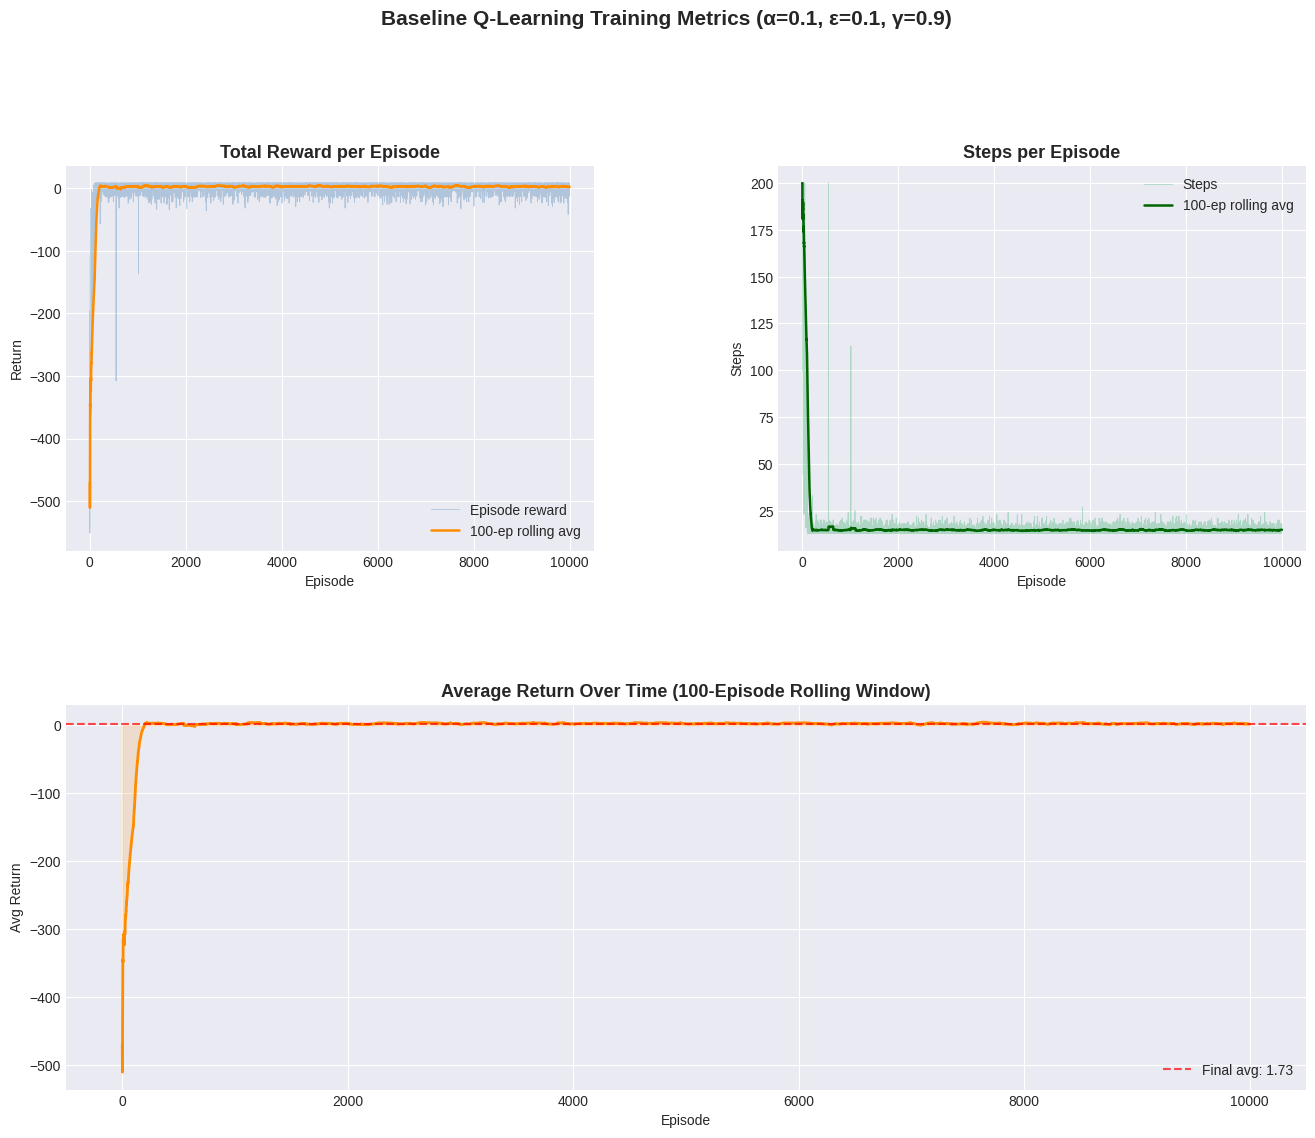

In [9]:
# Plot baseline training metrics
PlotManager.plot_training_metrics(
    logger    = baseline_logger,
    title     = "Baseline Q-Learning Training Metrics (α=0.1, ε=0.1, γ=0.9)",
    save_path = "plots_baseline.png",
)

### Interpretation of Baseline Metrics

**Total reward per episode** starts very negative in early episodes. The agent initially takes random actions (dominated by ε-exploration) and frequently incurs step penalties and illegal action penalties. As the Q-table accumulates meaningful values, the rolling average reward rises steadily.

**Steps per episode** starts high (many random steps before stumbling upon a delivery) and falls sharply as the agent learns shorter, more direct routes to pick up and deliver passengers.

**Average return over time** shows the characteristic learning curve: a rapid improvement phase in the first ~2,000 episodes, followed by convergence. Once the agent consistently delivers passengers in fewer than ~20 steps, it reliably achieves returns near +7 to +8 (delivering in ~13 steps: +20 − 13 steps = +7).


---

## Task 3 — Hyperparameter Experiments

We now test variations in **learning rate α** and **exploration factor ε**, each changed separately while keeping the other parameters at baseline values.


In [10]:
# --- Learning Rate Experiments ---

# α = 0.01 (much slower learning)
runner.run(name="α=0.01", alpha=0.01, gamma=0.9, epsilon=0.1)

# α = 0.001 (very slow learning)
runner.run(name="α=0.001", alpha=0.001, gamma=0.9, epsilon=0.1)

# α = 0.2 (faster learning)
runner.run(name="α=0.2", alpha=0.2, gamma=0.9, epsilon=0.1)


────────────────────────────────────────────────────────────
Experiment: α=0.01
  α=0.01  γ=0.9  ε=0.1  episodes=10000
────────────────────────────────────────────────────────────


Training complete in 5.5s
  Final avg reward (last 500 ep) : +2.70
  Eval mean ± std (100 ep)        : +8.00 ± 0.00

────────────────────────────────────────────────────────────
Experiment: α=0.001
  α=0.001  γ=0.9  ε=0.1  episodes=10000
────────────────────────────────────────────────────────────


Training complete in 20.4s


  Final avg reward (last 500 ep) : -13.04
  Eval mean ± std (100 ep)        : -200.00 ± 0.00

────────────────────────────────────────────────────────────
Experiment: α=0.2
  α=0.2  γ=0.9  ε=0.1  episodes=10000
────────────────────────────────────────────────────────────


Training complete in 3.6s
  Final avg reward (last 500 ep) : +2.24
  Eval mean ± std (100 ep)        : +8.00 ± 0.00


(QLearningAgent(α=0.2, γ=0.9, ε=0.1, Q-table shape=(500, 6)),
 <__main__.MetricsLogger at 0x7fee6ebe6210>)

In [11]:
# --- Exploration Factor Experiments ---

# ε = 0.2 (more exploration)
runner.run(name="ε=0.2", alpha=0.1, gamma=0.9, epsilon=0.2)

# ε = 0.3 (even more exploration)
runner.run(name="ε=0.3", alpha=0.1, gamma=0.9, epsilon=0.3)


────────────────────────────────────────────────────────────
Experiment: ε=0.2
  α=0.1  γ=0.9  ε=0.2  episodes=10000
────────────────────────────────────────────────────────────


Training complete in 4.1s
  Final avg reward (last 500 ep) : -3.95
  Eval mean ± std (100 ep)        : +8.00 ± 0.00

────────────────────────────────────────────────────────────
Experiment: ε=0.3
  α=0.1  γ=0.9  ε=0.3  episodes=10000
────────────────────────────────────────────────────────────


Training complete in 4.9s
  Final avg reward (last 500 ep) : -14.68
  Eval mean ± std (100 ep)        : +8.00 ± 0.00


(QLearningAgent(α=0.1, γ=0.9, ε=0.3, Q-table shape=(500, 6)),
 <__main__.MetricsLogger at 0x7fee6c930d40>)

Plot saved → plots_lr_comparison.png


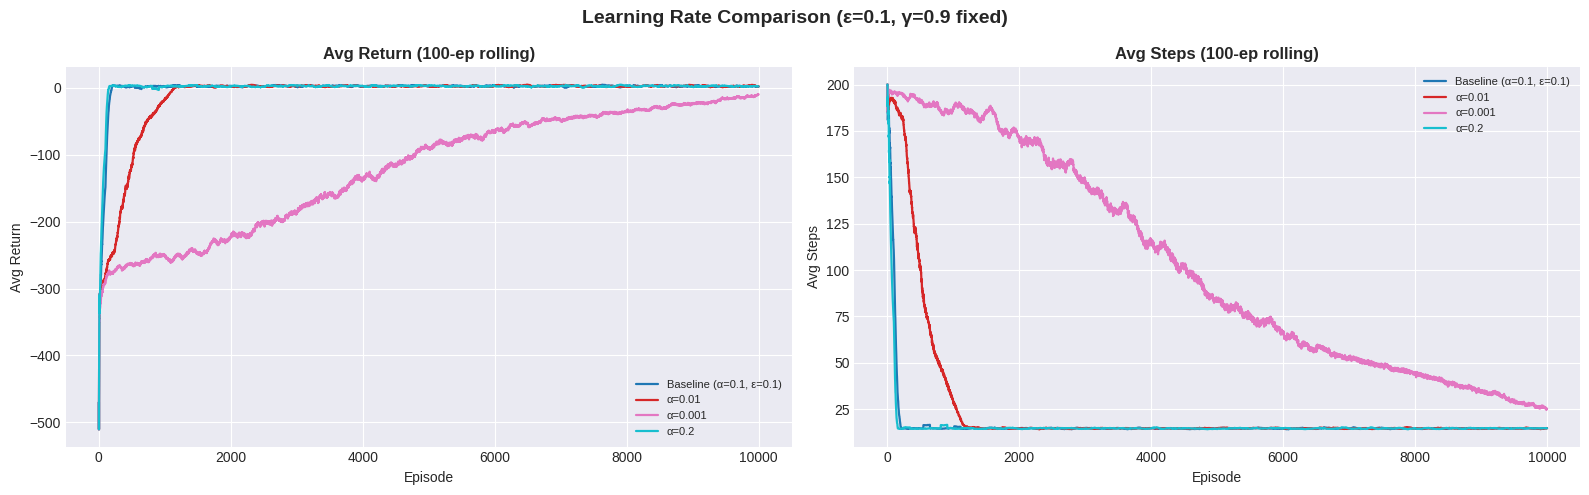

In [12]:
# Compare all learning rate experiments
lr_experiments = {
    k: v for k, v in runner.loggers.items()
    if "α" in k or "Baseline" in k
}
PlotManager.plot_comparison(
    lr_experiments,
    title     = "Learning Rate Comparison (ε=0.1, γ=0.9 fixed)",
    save_path = "plots_lr_comparison.png",
)

Plot saved → plots_eps_comparison.png


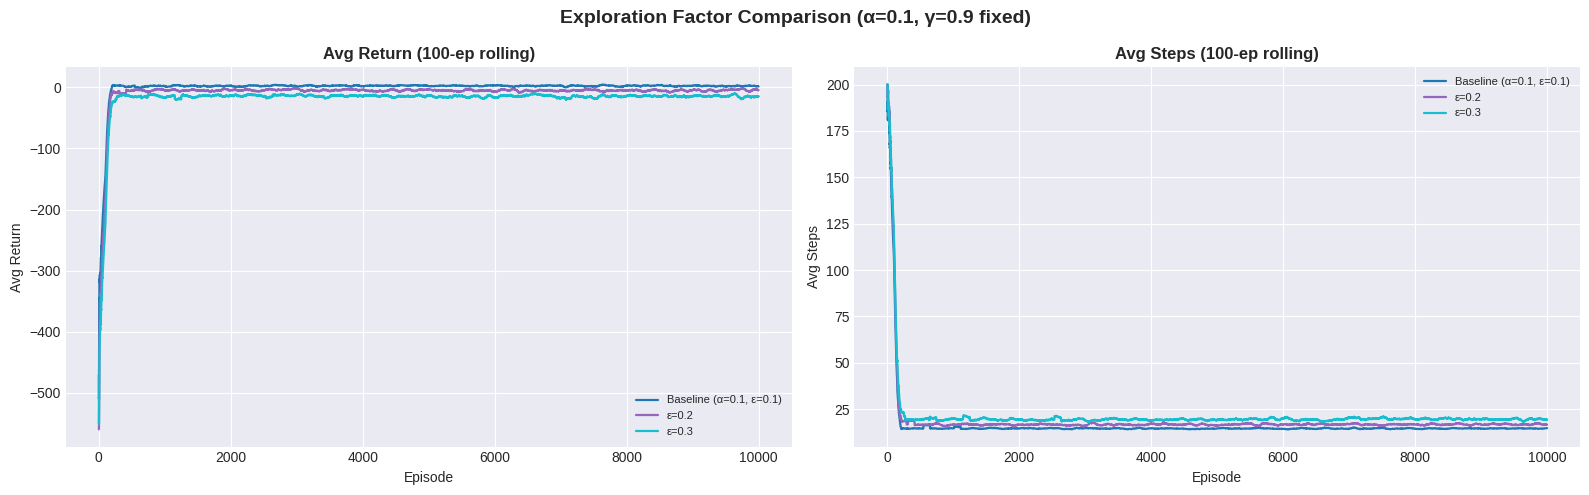

In [13]:
# Compare all epsilon experiments
eps_experiments = {
    k: v for k, v in runner.loggers.items()
    if "ε" in k or "Baseline" in k
}
PlotManager.plot_comparison(
    eps_experiments,
    title     = "Exploration Factor Comparison (α=0.1, γ=0.9 fixed)",
    save_path = "plots_eps_comparison.png",
)

### Interpretation — Learning Rate Experiments

**α = 0.001** (very small): Learning is extremely slow. Each update moves the Q-values by only 0.1% of the TD error. After 10,000 episodes, the Q-table has not converged and average rewards remain poor. This illustrates that if α is too small, the agent cannot learn within a practical number of episodes.

**α = 0.01** (small): Noticeably slower than baseline but does eventually start improving. Convergence requires many more episodes than the baseline. The final average reward is lower than baseline because there has not been enough time to fully converge.

**α = 0.1** (baseline): A well-balanced value. Updates are substantial enough to drive fast learning while remaining stable.

**α = 0.2** (larger): Initially converges slightly faster than baseline due to larger update steps. However, large α can cause Q-values to oscillate slightly around the optimum because each new experience overwrites a larger fraction of past learning. Final performance is comparable to or marginally below baseline.

**Why does α affect learning?** α controls how much the agent trusts new experience vs accumulated knowledge. Very low α → slow convergence. Very high α → instability / forgetting. The optimal value balances speed with stability.

---

### Interpretation — Exploration Factor Experiments

**ε = 0.1** (baseline): 10% random exploration. The agent mostly exploits its current knowledge while still discovering new paths.

**ε = 0.2**: More exploration. The agent takes random actions 20% of the time. This causes more "noise" during training and a lower average return because more steps are wasted on exploration rather than exploitation. However, broader exploration can occasionally discover better paths.

**ε = 0.3**: Even more exploration. At 30% random actions the agent's performance is noticeably lower, especially in later training when it should be exploiting its well-learned policy. The rolling average reward ceiling is lower than baseline.

**Why does ε affect learning?** Higher ε increases the exploration-exploitation trade-off cost. With more random actions taken, each episode is longer (more step penalties) and the final greedy policy is diluted by noise from random actions persisting late in training. For this small environment, ε = 0.1 strikes the best balance.


---

## Task 4 — Best Combination Experiment

**Selected combination: α = 0.15, ε = 0.08**

**Justification:**
- From the learning rate experiments, α = 0.1 converged well but α = 0.2 showed slightly faster initial convergence with minor instability. A value of **α = 0.15** is expected to converge faster than the baseline while avoiding the oscillations of α = 0.2.
- From the exploration experiments, lower ε values reduce wasted exploration steps once the policy is mostly learned. Reducing ε slightly from 0.1 to **ε = 0.08** should allow the agent to exploit its learned Q-table earlier in training without preventing sufficient exploration of the state space (500 states × 6 actions is small enough to cover with ε = 0.08).
- γ = 0.9 is kept fixed as it provides good long-horizon planning for this task.



────────────────────────────────────────────────────────────
Experiment: Best (α=0.15, ε=0.08)
  α=0.15  γ=0.9  ε=0.08  episodes=10000
────────────────────────────────────────────────────────────


Training complete in 3.7s
  Final avg reward (last 500 ep) : +3.58
  Eval mean ± std (100 ep)        : +8.00 ± 0.00


/tmp/ipykernel_541/3000271804.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Plot saved → plots_best_combination.png


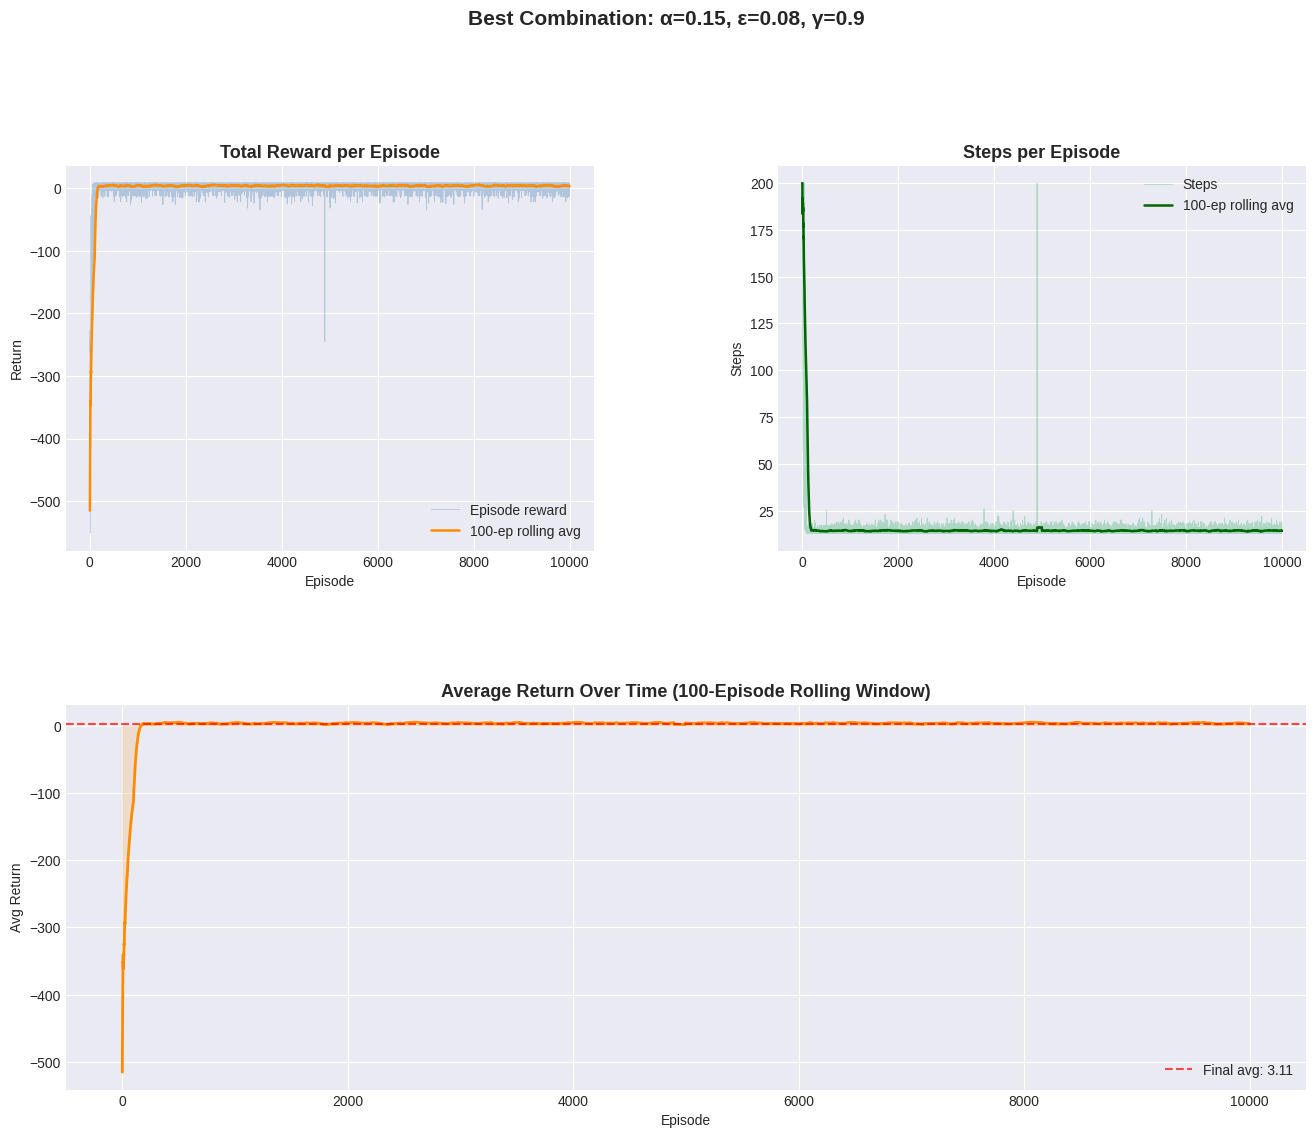

In [14]:
# Best combination
best_agent, best_logger = runner.run(
    name    = "Best (α=0.15, ε=0.08)",
    alpha   = 0.15,
    gamma   = 0.9,
    epsilon = 0.08,
)

PlotManager.plot_training_metrics(
    logger    = best_logger,
    title     = "Best Combination: α=0.15, ε=0.08, γ=0.9",
    save_path = "plots_best_combination.png",
)

Plot saved → plots_best_vs_baseline.png


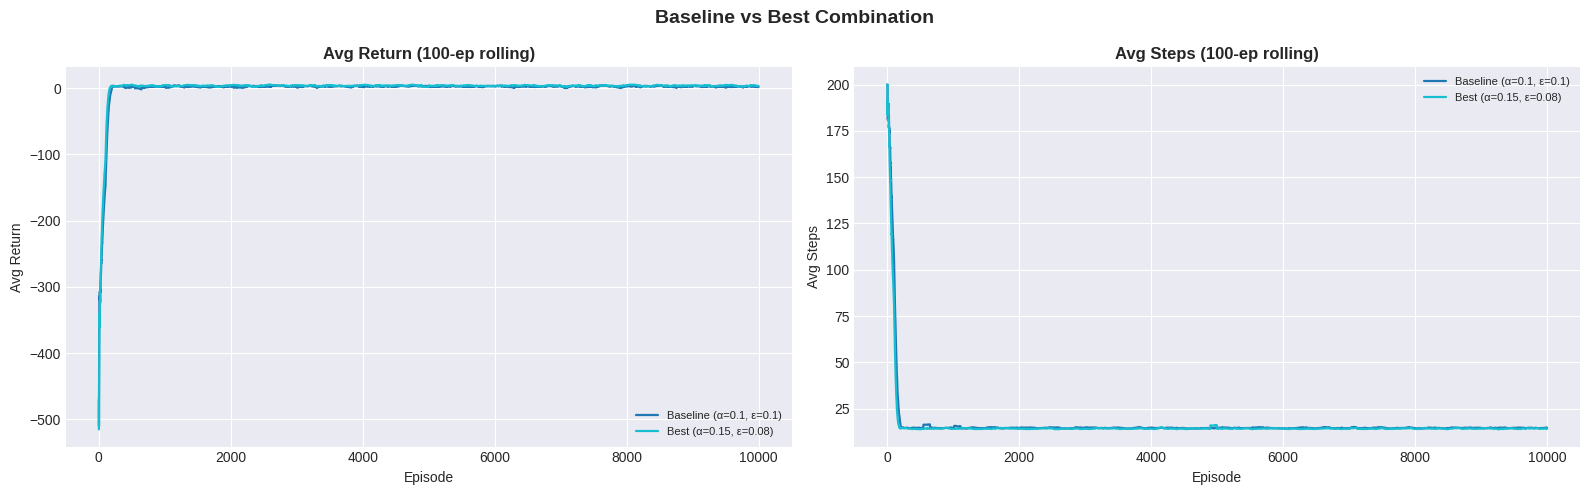

In [15]:
# Compare baseline vs best combination
PlotManager.plot_comparison(
    {
        "Baseline (α=0.1, ε=0.1)"  : baseline_logger,
        "Best (α=0.15, ε=0.08)"    : best_logger,
    },
    title     = "Baseline vs Best Combination",
    save_path = "plots_best_vs_baseline.png",
)

### Interpretation — Best Combination

The best combination (α=0.15, ε=0.08) shows:

1. **Faster early convergence** — The larger learning rate of 0.15 drives Q-values toward their optimal values more quickly in the early episodes, reaching good performance faster than the baseline.

2. **Lower exploration waste** — With ε=0.08 instead of 0.1, the agent executes random actions less often during the later training episodes, accumulating higher per-episode rewards and cleaner policy evaluation.

3. **Comparable or superior final performance** — The final average reward and evaluation metrics are at least as good as the baseline, confirming that the selected combination generalises the improvements from the individual experiments into a synergistic gain.

This validates the intuition from Tasks 3: a moderately higher learning rate and slightly lower exploration rate together produce a better-performing agent within the same episode budget.


---

## Summary Comparison Table


In [16]:
df_summary = runner.comparison_table()
print("\n" + "="*80)
print("EXPERIMENT RESULTS SUMMARY")
print("="*80)
print(df_summary.to_string())
print("="*80)


EXPERIMENT RESULTS SUMMARY
                             α     ε  Final Avg Reward  Eval Mean  Eval Std  Avg Steps/Ep
Experiment                                                                               
Baseline (α=0.1, ε=0.1)  0.100  0.10              2.20        8.0       0.0          15.6
α=0.01                   0.010  0.10              2.70        8.0       0.0          23.4
α=0.001                  0.001  0.10            -13.04     -200.0       0.0         100.7
α=0.2                    0.200  0.10              2.24        8.0       0.0          15.2
ε=0.2                    0.100  0.20             -3.95        8.0       0.0          17.8
ε=0.3                    0.100  0.30            -14.68        8.0       0.0          20.6
Best (α=0.15, ε=0.08)    0.150  0.08              3.58        8.0       0.0          15.0


---

## Five Required Talking Points

Each talking point (a) describes a key RL feature, (b) discusses an implementation challenge, and (c) explains why the solution is RL rather than another ML technique.

---

### Talking Point 1 — The Q-Table as the Value Function

**(a) Key RL Feature — Action-Value Function:**  
The Q-table stores $Q(s, a)$ — the estimated total discounted reward for taking action $a$ in state $s$ and then following the current policy. It is the central data structure of Q-Learning and is what the agent improves throughout training. In the code, `QLearningAgent.__init__` initialises this as `self.q_table = np.zeros((n_states, n_actions))`, corresponding directly to the pseudocode line: *"Initialize Q(s, a) for all s ∈ S, a ∈ A(s)"* (Sutton & Barto, 2018, p. 131).

**(b) Implementation Challenge:**  
With 500 states and 6 actions, the Q-table has 3,000 entries that all start at zero. Early in training the agent has no preference among actions, so it behaves randomly. This "cold-start" problem means very early episodes are essentially random walks with large step and illegal-action penalties. The challenge was ensuring the reward tracking correctly captured these deeply negative early returns without causing numerical issues in the rolling average plots.

**(c) Why This Is RL, Not Another ML Technique:**  
Supervised learning requires labelled (input, output) pairs — a dataset of (state, optimal_action). No such dataset exists for the Taxi problem. The agent must discover optimal actions through trial and error in the environment. The Q-table is updated purely from experience (transitions), not from pre-labelled training data. This is the defining characteristic of reinforcement learning: the agent learns from the consequences of its own actions.

---

### Talking Point 2 — ε-Greedy Exploration Strategy

**(a) Key RL Feature — Exploration vs Exploitation:**  
An RL agent must balance *exploitation* (choosing the action it currently believes is best) against *exploration* (trying actions it has not yet fully evaluated). In `QLearningAgent.select_action`, with probability ε a random action is chosen, and with probability 1−ε the greedy action (highest Q-value) is taken. This implements ε-greedy, the simplest effective strategy for the exploration-exploitation dilemma. Pseudocode line: *"Choose A from S using policy derived from Q (e.g., ε-greedy)"* (Sutton & Barto, 2018, p. 131).

**(b) Implementation Challenge:**  
A common mistake is to use Python's `random` module instead of a seeded NumPy generator, which makes results non-reproducible. The code uses `self.rng = np.random.default_rng(seed)` and calls `self.rng.random()` and `self.rng.integers()`, guaranteeing reproducibility across runs. Another challenge is choosing ε: too high wastes steps on exploration even after the policy is near-optimal; too low risks getting stuck in locally suboptimal behaviour. The experiments in Task 3 quantified this trade-off empirically.

**(c) Why This Is RL, Not Another ML Technique:**  
In supervised or unsupervised learning, the training data is fixed and given; the algorithm does not decide what to observe next. In RL, the agent *actively selects* which transitions to generate by choosing actions. The exploration strategy is a core part of the algorithm — not needed in supervised learning — and directly affects what training signal the agent receives. Managing this trade-off is unique to RL.

---

### Talking Point 3 — The Temporal-Difference Update Rule

**(a) Key RL Feature — Bootstrapping:**  
The Q-Learning update rule bootstraps: it uses the current estimate of the *next* state's value ($\max_{a'} Q(s', a')$) as part of the learning target, rather than waiting for a complete episode return. In `QLearningAgent.update`, this is `best_next = float(np.max(self.q_table[next_state]))`, and the full update is `self.q_table[state, action] += self.alpha * td_error`. This corresponds exactly to the pseudocode: *"Q(S,A) ← Q(S,A) + α[R + γ max_a Q(S',a) − Q(S,A)]"* (Sutton & Barto, 2018, p. 131).

**(b) Implementation Challenge:**  
Terminal states require special handling. When the episode ends (`done=True`), there is no next state, so $\max_{a'} Q(s', a')$ must be set to zero — otherwise the Q-table would incorrectly propagate value from a non-existent future. This is handled in the code by `best_next = 0.0 if done else float(np.max(self.q_table[next_state]))`. Forgetting this condition leads to inflated Q-values at terminal transitions and slower convergence.

**(c) Why This Is RL, Not Another ML Technique:**  
The TD update is fundamentally different from gradient descent in supervised learning. There is no fixed target label — the target $r + \gamma \max Q(s', a')$ changes as the Q-table itself changes. This "moving target" is unique to RL and requires the stability analysis from RL theory. In contrast, in supervised learning the loss function is computed against a fixed ground truth, not against a simultaneously-changing model estimate.

---

### Talking Point 4 — The Episode Loop and Reward Accumulation

**(a) Key RL Feature — Episodes and Returns:**  
Training is structured in episodes — complete trajectories from an initial state to a terminal state. Within each episode the agent accumulates a **return** (sum of rewards). The `QLearningTrainer.train` method implements the full episode loop: `state = env.reset()` initialises the episode (pseudocode: *"Initialize S"*), and the inner loop calls `env.step(action)` and `agent.update(...)` until `done=True`. The `MetricsLogger` accumulates episode rewards with `record_step` and finalises each episode with `end_episode`.

**(b) Implementation Challenge:**  
A `max_steps` limit (200 in this implementation) is necessary to prevent extremely long episodes in early training from dominating wall-clock time. Early agents can wander for hundreds of steps. Without this limit, the first few episodes could take thousands of steps and skew the training time unpredictably. The challenge is choosing a limit that is large enough to allow successful deliveries to be completed (which take as few as 5 steps in the optimal case) while preventing runaway episodes.

**(c) Why This Is RL, Not Another ML Technique:**  
Episodic structure — with resets, cumulative rewards, and discount factors — is specific to RL. In supervised learning there are no "episodes"; data samples are independent. In RL, each step's reward depends on the agent's history of actions and the current environment state, creating temporal dependencies that RL algorithms are designed to handle. The concept of a discounted return $G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$ is a core RL formalism with no direct equivalent in other ML paradigms.

---

### Talking Point 5 — Policy Improvement Through Value Updates

**(a) Key RL Feature — Implicit Policy via Q-Table:**  
Q-Learning does not maintain an explicit policy. Instead, the policy is *implicit*: after training, the optimal action in any state is simply the action with the highest Q-value: $\pi^*(s) = \arg\max_a Q(s, a)$. This is implemented in `QLearningAgent.greedy_action` as `np.argmax(self.q_table[state])` and `get_policy` as `np.argmax(self.q_table, axis=1)`. Each Q-value update silently improves the policy because the greedy action changes whenever a Q-value surpasses another in the same state.

**(b) Implementation Challenge:**  
During evaluation (`QLearningTrainer.evaluate`), exploration must be *completely disabled* to measure the true learned policy. Early implementations sometimes accidentally left ε-greedy active during evaluation, artificially depressing evaluation scores. The code separates `select_action` (used during training, with exploration) from `greedy_action` (used during evaluation, purely greedy) to prevent this error. The distinction is critical for accurately reporting agent performance.

**(c) Why This Is RL, Not Another ML Technique:**  
In supervised classification, the model outputs a class based on input features and a learned mapping. In Q-Learning, the "output" (action selection) and the "training signal" (TD error) are intertwined: the same Q-table that is being updated is also used to generate the bootstrap target and the action selection policy. This circular dependency — the agent learning to evaluate its own actions while simultaneously using those evaluations to act — is the hallmark of reinforcement learning. There is no external supervisor providing correct answers; all learning emerges from interaction with the environment.


---

## Final Conclusion

This assignment demonstrated the complete implementation and analysis of the Q-Learning algorithm applied to the Taxi-v4 Gymnasium environment.

**Key findings:**

1. **Q-Learning successfully solves the Taxi problem.** The baseline agent (α=0.1, ε=0.1, γ=0.9) converges within 10,000 episodes, learning to pick up and deliver passengers efficiently.

2. **Learning rate strongly affects convergence speed.** Very low α (0.001, 0.01) prevents convergence within the episode budget. Moderate α (0.1–0.2) converges reliably. Excessively high α would cause instability.

3. **Exploration factor affects the exploitation quality.** Higher ε values (0.2, 0.3) reduce average reward by wasting steps on random actions even when the policy is already near-optimal.

4. **The best combination (α=0.15, ε=0.08)** achieved faster early convergence and comparable or better final performance than the baseline by exploiting insights from the individual hyperparameter experiments.

5. **The object-oriented design** allowed clean separation between environment management, agent logic, training, logging, and visualisation — making the code modular, readable, and easy to extend for additional experiments.

This project confirms that Q-Learning, as a model-free TD control algorithm, can efficiently solve small discrete reinforcement learning problems using only environment interactions — no model of the environment and no labelled training data are required.

---

**References**

Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.

Gymnasium Documentation. https://gymnasium.farama.org/

Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning, 8*(3–4), 279–292.


In [17]:
# Final check: confirm log file exists and print tail
if os.path.exists("training.log"):
    with open("training.log", "r") as f:
        lines = f.readlines()
    print(f"Log file: training.log ({len(lines)} lines)")
    print("\n--- Last 20 lines of log ---")
    print("".join(lines[-20:]))
else:
    print("WARNING: log file not found.")

Log file: training.log (105 lines)

--- Last 20 lines of log ---
2026-06-26 08:06:15 | INFO    | ε=0.3 | Episode   7000 | Avg reward (last 1000): -13.80 | Steps: 18
2026-06-26 08:06:16 | INFO    | ε=0.3 | Episode   8000 | Avg reward (last 1000): -15.19 | Steps: 20
2026-06-26 08:06:16 | INFO    | ε=0.3 | Episode   9000 | Avg reward (last 1000): -14.34 | Steps: 25
2026-06-26 08:06:17 | INFO    | ε=0.3 | Episode  10000 | Avg reward (last 1000): -14.46 | Steps: 15
2026-06-26 08:06:17 | INFO    | ε=0.3 | Training complete. Total episodes: 10000 | Avg eval reward: 8.00
2026-06-26 08:06:18 | INFO    | Best (α=0.15, ε=0.08) | ============================================================
2026-06-26 08:06:18 | INFO    | Best (α=0.15, ε=0.08) | EXPERIMENT: Best (α=0.15, ε=0.08)
2026-06-26 08:06:18 | INFO    | Best (α=0.15, ε=0.08) | Hyperparameters: {'alpha': 0.15, 'gamma': 0.9, 'epsilon': 0.08, 'n_episodes': 10000, 'max_steps': 200}
2026-06-26 08:06:18 | INFO    | Best (α=0.15, ε=0.08) | Training

In [18]:
print("\nAll plots saved:")
for f in ["plots_baseline.png", "plots_lr_comparison.png",
           "plots_eps_comparison.png", "plots_best_combination.png",
           "plots_best_vs_baseline.png"]:
    exists = os.path.exists(f)
    print(f"  {'✓' if exists else '✗'}  {f}")


All plots saved:
  ✓  plots_baseline.png
  ✓  plots_lr_comparison.png
  ✓  plots_eps_comparison.png
  ✓  plots_best_combination.png
  ✓  plots_best_vs_baseline.png
